<a href="https://colab.research.google.com/github/syedarhabjafri/supply-chain-analytics-SAUJ/blob/main/00-%20Initial%20Work/Wallmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("Walmart_Store_sales.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
STORE_ID = 36
store_df = df[df["Store"] == STORE_ID].sort_values("Date").reset_index(drop=True)
print(store_df.shape)
print(store_df.head())

(143, 8)
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0     36 2010-02-05     467546.74             0        45.97       2.545   
1     36 2010-02-12     469563.70             1        46.11       2.539   
2     36 2010-02-19     470281.03             0        45.66       2.472   
3     36 2010-02-26     447519.44             0        50.87       2.520   
4     36 2010-03-05     480203.43             0        51.33       2.574   

          CPI  Unemployment  
0  209.852966         8.554  
1  209.997021         8.554  
2  210.045102         8.554  
3  210.077189         8.554  
4  210.109275         8.554  


In [3]:
train = store_df.iloc[:-12]
test = store_df.iloc[-12:]
print("Train weeks:", len(train), "| Test weeks:", len(test))

Train weeks: 131 | Test weeks: 12


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import numpy as np

### 1. Simple Moving Average (4-week window)

In [5]:
# Calculate the 4-week Simple Moving Average on the training data
# For forecasting, we will use the last 4 weeks of the training data to get the average
sma_window = 4
last_4_weeks_sales = train['Weekly_Sales'].iloc[-sma_window:]
sma_forecast_value = last_4_weeks_sales.mean()

# Extend this forecast value for the 12 weeks of the test set
sma_forecast = np.array([sma_forecast_value] * len(test))

print(f"SMA Forecast (last {sma_window} weeks average): {sma_forecast_value:.2f}")
print(f"SMA Forecast for 12 weeks: {sma_forecast}")

SMA Forecast (last 4 weeks average): 296565.09
SMA Forecast for 12 weeks: [296565.09 296565.09 296565.09 296565.09 296565.09 296565.09 296565.09
 296565.09 296565.09 296565.09 296565.09 296565.09]


### 2. Simple Exponential Smoothing

In [6]:
# Simple Exponential Smoothing with alpha = 0.3
fit_ses_03 = SimpleExpSmoothing(train['Weekly_Sales'], initialization_method="estimated").fit(smoothing_level=0.3, optimized=False)
ses_forecast_03 = fit_ses_03.predict(start=len(train), end=len(train) + len(test) - 1)

print("SES Forecast (alpha=0.3):")
print(ses_forecast_03.values)

# Simple Exponential Smoothing with alpha = 0.6
fit_ses_06 = SimpleExpSmoothing(train['Weekly_Sales'], initialization_method="estimated").fit(smoothing_level=0.6, optimized=False)
ses_forecast_06 = fit_ses_06.predict(start=len(train), end=len(train) + len(test) - 1)

print("\nSES Forecast (alpha=0.6):")
print(ses_forecast_06.values)

SES Forecast (alpha=0.3):
[299862.0894552 299862.0894552 299862.0894552 299862.0894552
 299862.0894552 299862.0894552 299862.0894552 299862.0894552
 299862.0894552 299862.0894552 299862.0894552 299862.0894552]

SES Forecast (alpha=0.6):
[298475.11622101 298475.11622101 298475.11622101 298475.11622101
 298475.11622101 298475.11622101 298475.11622101 298475.11622101
 298475.11622101 298475.11622101 298475.11622101 298475.11622101]


### 3. Seasonal Naive / Seasonal Decomposition Forecast (accounting for Holiday_Flag)

This approach incorporates the `Holiday_Flag` by calculating the average `Weekly_Sales` for holiday weeks and non-holiday weeks separately from the training data. For each week in the test set, the forecast will be the corresponding average based on its `Holiday_Flag` status.

In [7]:
# Calculate average sales for holiday and non-holiday weeks from the training data
avg_holiday_sales = train[train['Holiday_Flag'] == 1]['Weekly_Sales'].mean()
avg_non_holiday_sales = train[train['Holiday_Flag'] == 0]['Weekly_Sales'].mean()

# Handle cases where there might be no holidays or non-holidays in the training set
# (though unlikely for this dataset, it's good practice)
if pd.isna(avg_holiday_sales):
    print("Warning: No holiday weeks found in training data. Using overall training mean for holiday forecasts.")
    avg_holiday_sales = train['Weekly_Sales'].mean()
if pd.isna(avg_non_holiday_sales):
    print("Warning: No non-holiday weeks found in training data. Using overall training mean for non-holiday forecasts.")
    avg_non_holiday_sales = train['Weekly_Sales'].mean()

# Generate seasonal naive forecast for the test set based on Holiday_Flag
seasonal_naive_forecast = []
for _, row in test.iterrows():
    if row['Holiday_Flag'] == 1:
        seasonal_naive_forecast.append(avg_holiday_sales)
    else:
        seasonal_naive_forecast.append(avg_non_holiday_sales)

seasonal_naive_forecast = np.array(seasonal_naive_forecast)

print("Seasonal Naive Forecast (Holiday_Flag based):")
print(seasonal_naive_forecast)

Seasonal Naive Forecast (Holiday_Flag based):
[381585.74327869 381585.74327869 381585.74327869 381585.74327869
 375853.08111111 381585.74327869 381585.74327869 381585.74327869
 381585.74327869 381585.74327869 381585.74327869 381585.74327869]


### Plotting All Forecasts vs Actuals

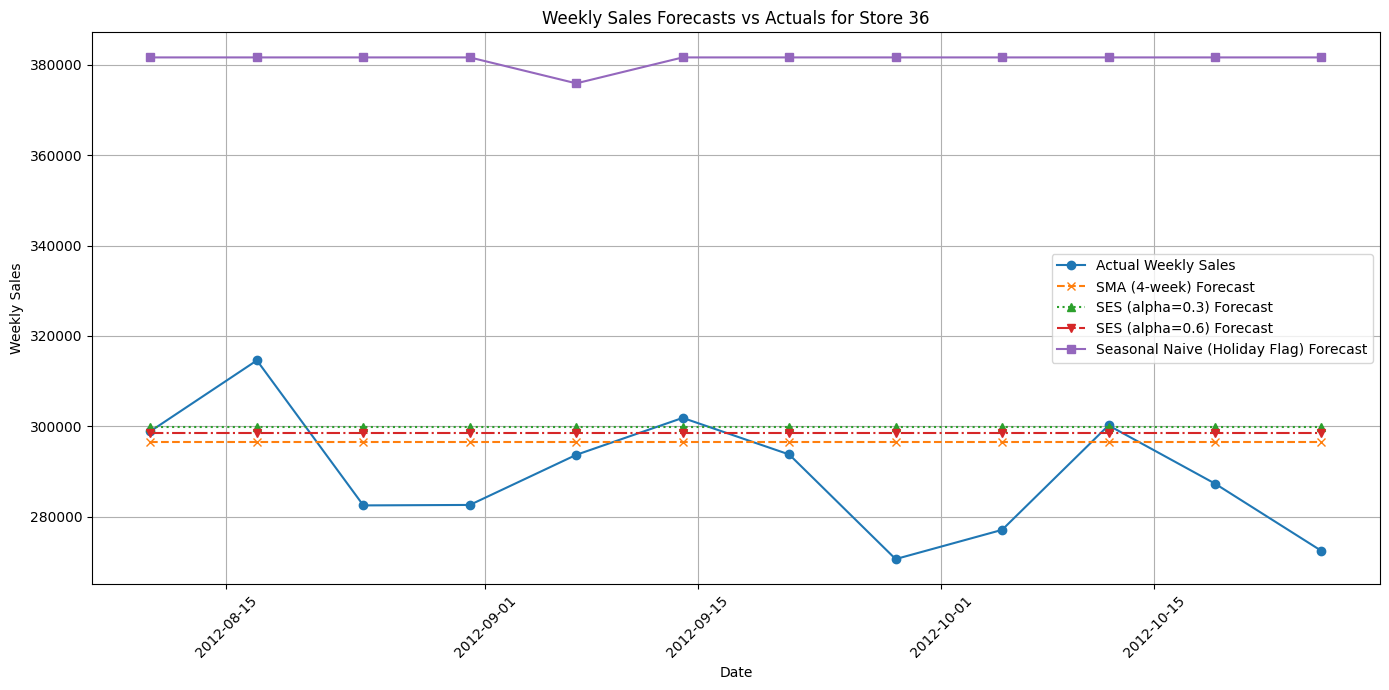

In [8]:
plt.figure(figsize=(14, 7))
plt.plot(test['Date'], test['Weekly_Sales'], label='Actual Weekly Sales', marker='o', linestyle='-')
plt.plot(test['Date'], sma_forecast, label='SMA (4-week) Forecast', marker='x', linestyle='--')
plt.plot(test['Date'], ses_forecast_03, label='SES (alpha=0.3) Forecast', marker='^', linestyle=':')
plt.plot(test['Date'], ses_forecast_06, label='SES (alpha=0.6) Forecast', marker='v', linestyle='-.')
plt.plot(test['Date'], seasonal_naive_forecast, label='Seasonal Naive (Holiday Flag) Forecast', marker='s', linestyle='-')

plt.title('Weekly Sales Forecasts vs Actuals for Store ' + str(STORE_ID))
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Calculate Mean Absolute Percentage Error (MAPE)

In [9]:
def calculate_mape(y_true, y_pred):
    # Ensure inputs are numpy arrays for element-wise operations
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero: replace 0 true values with a small epsilon or filter them out
    # Here, we'll filter out cases where y_true is 0 to avoid NaNs or Infs
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Calculate MAPE for each forecast
mape_sma = calculate_mape(test['Weekly_Sales'], sma_forecast)
mape_ses_03 = calculate_mape(test['Weekly_Sales'], ses_forecast_03)
mape_ses_06 = calculate_mape(test['Weekly_Sales'], ses_forecast_06)
mape_seasonal_naive = calculate_mape(test['Weekly_Sales'], seasonal_naive_forecast)

# Create a DataFrame for comparison
mape_results = pd.DataFrame({
    'Method': ['Simple Moving Average', 'Simple Exponential Smoothing (alpha=0.3)',
               'Simple Exponential Smoothing (alpha=0.6)', 'Seasonal Naive (Holiday Flag)'],
    'MAPE (%)': [mape_sma, mape_ses_03, mape_ses_06, mape_seasonal_naive]
})

# Sort by MAPE from most accurate (lowest) to least accurate (highest)
mape_results_sorted = mape_results.sort_values(by='MAPE (%)').reset_index(drop=True)

display(mape_results_sorted)

,Method,MAPE (%)
0,Simple Moving Average,4.160288
1,Simple Exponential Smoothing (alpha=0.6),4.401766
2,Simple Exponential Smoothing (alpha=0.3),4.628105
3,Seasonal Naive (Holiday Flag),31.817318
